# Downloading libraries

In [1]:
import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
from collections import Counter
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import re
import warnings
nlp = spacy.load("en_core_web_sm")

# LOAD DATASET

In [4]:
#Using the BBC News dataset
from sklearn.datasets import fetch_20newsgroups # placeholder
df = pd.read_csv("week6.csv")

In [6]:
#print(df["entities"][0])

# 1. Function to clean text for LDA later

In [7]:
def clean_description(description):
    if pd.isna(description):
        return ""
    description = re.sub(r'\s+', ' ', description).strip()
    return description


# 2. Function to extract NER

In [8]:
def extract_entities(description):
    if pd.isna(description):
        return []
    doc = nlp(description)
    entities = [(ent.text, ent.label_) for ent in doc.ents 
                if ent.label_ in ["PERSON", "ORG", "GPE", "LOC", "DATE"]]
    return entities


# Named_Entity_Recognition

In [9]:
from tqdm import tqdm
tqdm.pandas()

# 1. This one is already fast
df['clean_description'] = df['description'].apply(clean_description)

# 2. FAST NER with batching
print("Running NER on all descriptions...")
entities_list = []

for doc in tqdm(nlp.pipe(df['description'].dropna().tolist(), batch_size=50)):
    ents = [(ent.text, ent.label_) for ent in doc.ents 
            if ent.label_ in ["PERSON", "ORG", "GPE", "LOC", "DATE"]]
    entities_list.append(ents)

df['entities'] = entities_list
print("NER Done!")

Running NER on all descriptions...


42115it [04:22, 160.62it/s]

NER Done!


# Most frequent entities overall

In [10]:
all_ents = [e[0] for ents in df['entities'] for e in ents]
Counter(all_ents).most_common(20)

[('England', 2075),
 ('UK', 1657),
 ('BBC', 1639),
 ('US', 1038),
 ('Ukraine', 983),
 ('Russia', 700),
 ('London', 487),
 ('Israel', 477),
 ('Liverpool', 453),
 ('Saturday', 430),
 ('Sunday', 426),
 ('Scotland', 415),
 ('Wales', 399),
 ('Labour', 399),
 ('Manchester United', 365),
 ('Manchester City', 363),
 ('France', 357),
 ('Gaza', 353),
 ('Chelsea', 338),
 ('2024', 326)]

# *PART 2 — Topic Modeling with LDA*

In [11]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess_for_lda(text):
    tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return tokens
df['tokens'] = df['clean_description'].apply(preprocess_for_lda)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 2. LDA

In [12]:
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(t) for t in df['tokens']]
lda = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15, random_state=42)

# Visualize top keywords

In [13]:
for idx, topic in lda.print_topics(-1):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.024*"year" + 0.013*"old" + 0.010*"star" + 0.008*"died" + 0.006*"one" + 0.005*"found" + 0.005*"two" + 0.005*"king" + 0.005*"week" + 0.004*"israeli"
Topic 1: 0.023*"say" + 0.014*"people" + 0.007*"new" + 0.007*"strike" + 0.005*"could" + 0.005*"pay" + 0.004*"one" + 0.004*"cost" + 0.004*"rise" + 0.004*"due"
Topic 2: 0.015*"say" + 0.011*"president" + 0.011*"bbc" + 0.010*"police" + 0.008*"people" + 0.008*"attack" + 0.008*"said" + 0.007*"killed" + 0.006*"day" + 0.006*"war"
Topic 3: 0.020*"say" + 0.011*"party" + 0.011*"bbc" + 0.010*"election" + 0.009*"government" + 0.009*"minister" + 0.008*"leader" + 0.008*"first" + 0.007*"former" + 0.007*"israel"
Topic 4: 0.018*"england" + 0.016*"world" + 0.013*"win" + 0.011*"final" + 0.011*"league" + 0.010*"manchester" + 0.009*"first" + 0.009*"cup" + 0.008*"city" + 0.007*"match"


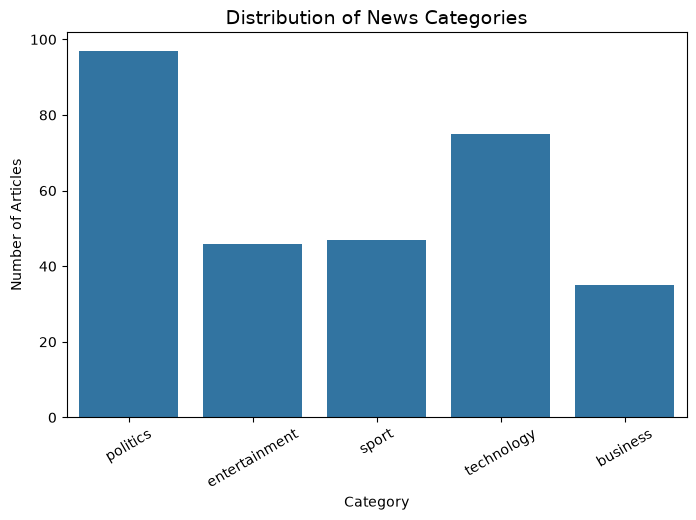

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(data=df.head(300), x='category', order=df['category'].value_counts().index)
plt.title("Distribution of News Categories", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=30)
plt.show()

# Assign dominant topic and compare to category

In [14]:
def get_dominant_topic(lda_model, corpus):
    topics = []
    for bow in corpus:
        topic_probs = lda_model.get_document_topics(bow)
        dominant = max(topic_probs, key=lambda x: x[1])[0]
        topics.append(dominant)
    return topics
df['dominant_topic'] = get_dominant_topic(lda, corpus)
#pd.crosstab(df['category'], df['dominant_topic'])

In [15]:
cm = CoherenceModel(model=lda, texts=df['tokens'], dictionary=dictionary, coherence='c_v')
print("Coherence Score:", cm.get_coherence())

Coherence Score: 0.3633617275045846


# Map topic numbers to real category names

In [19]:
topic_map = {
    0: 'business',
    1: 'technology', 
    2: 'politics',
    3: 'entertainment',
    4: 'sport'
}

# Create new category column
df['category'] = df['dominant_topic'].map(topic_map)

print("New columns:", df.columns.tolist())
print("\nCategory counts:")
print(df['category'].value_counts())

New columns: ['title', 'pubDate', 'guid', 'link', 'description', 'clean_description', 'entities', 'tokens', 'dominant_topic', 'category']

Category counts:
category
politics         9553
entertainment    8952
sport            8876
technology       8652
business         6082
Name: count, dtype: int64


# Use only 500 articles to be fast

In [20]:
df_small = df.head(500)

X = df_small['description']
y = df_small['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 2. Logistic Regression Model
model = LogisticRegression(max_iter=300)
model.fit(X_train_tfidf, y_train)

# 3. Evaluate
preds = model.predict(X_test_tfidf)
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, preds))
print("Accuracy:", accuracy_score(y_test, preds))

--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

     business       0.50      0.11      0.18         9
entertainment       0.14      0.08      0.11        12
     politics       0.52      0.91      0.66        33
        sport       0.93      0.65      0.76        20
   technology       0.79      0.58      0.67        26

     accuracy                           0.60       100
    macro avg       0.58      0.47      0.48       100
 weighted avg       0.62      0.60      0.57       100

Accuracy: 0.6


# Baseline: TF-IDF + Logistic Regression

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. First create category column from LDA topics if you haven't already
topic_map = {0: 'business', 1: 'technology', 2: 'politics', 3: 'entertainment', 4: 'sport'}
df['category'] = df['dominant_topic'].map(topic_map)

# 2. Use only 300 articles to keep it fast
df_small = df.head(300)

# 3. Split into train and test
train_df, test_df = train_test_split(df_small, test_size=0.2, random_state=42)

# 4. TF-IDF on description column
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_train = tfidf.fit_transform(train_df['description']) # changed from clean_text
X_test = tfidf.transform(test_df['description'])

# 5. Logistic Regression on category column
clf = LogisticRegression(max_iter=300)
clf.fit(X_train, train_df['category']) # changed from label
y_pred_base = clf.predict(X_test)

# #4. Evaluate
print("Baseline Accuracy:", accuracy_score(test_df['category'], y_pred_base))
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(test_df['category'], y_pred_base))

Baseline Accuracy: 0.5

--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

     business       0.00      0.00      0.00         7
entertainment       1.00      0.10      0.18        10
     politics       0.32      1.00      0.48        13
        sport       1.00      0.50      0.67        14
   technology       0.82      0.56      0.67        16

     accuracy                           0.50        60
    macro avg       0.63      0.43      0.40        60
 weighted avg       0.69      0.50      0.47        60



C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

# Confusion matrix

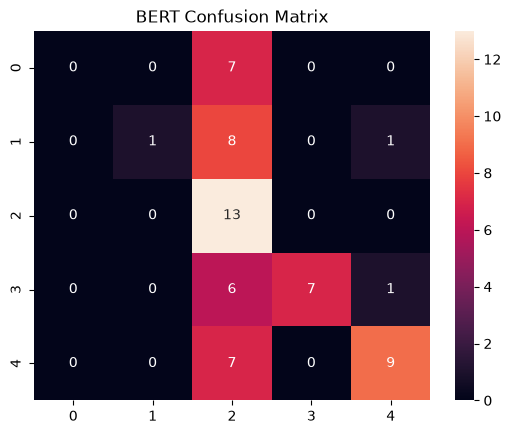

In [26]:
sns.heatmap(confusion_matrix(test_df['category'], y_pred_base), annot=True, fmt='d')
plt.title("BERT Confusion Matrix")
plt.show()

# Save best model

In [28]:
import joblib

# Save the model and vectorizer
joblib.dump(clf, 'best_logreg_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model saved as 'best_logreg_model.pkl'")
print("Vectorizer saved as 'tfidf_vectorizer.pkl'")

Model saved as 'best_logreg_model.pkl'
Vectorizer saved as 'tfidf_vectorizer.pkl'
